In [25]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
import pickle
from src.operations2d import ImageChunk
from src.util import read_video_frames, display_image, get_character_placeholder, read_trimesh
from src.operations2d import get_2d_bounding_boxes, bounding_boxes_to_image_chunks, find_similar_image_chunk
from src.operations3d import get_intrinsics_for_chunk, apply_mesh_transforms, adjust_transforms_by_chunk_rotation

In [27]:
video_path = "vids/moving_objects/wooden_cabinet.mp4"
frames = read_video_frames(video_path)
previous_frame = frames[0]
next_frame = frames[1]

In [28]:
# read mesh data from pkl
input_pkl = "output/wooden_cabinet.pkl"
with open(input_pkl, 'rb') as f:
            frames_data = pickle.load(f)
            
class_data = frames_data[0]["classes"][0]
object_class = class_data["class_name"]
mesh_data = class_data["reconstructed_meshes"][0]

unposed_path = mesh_data.get("unposed_mesh_path")
scale = mesh_data.get("scale")
rotation = mesh_data.get("rotation")
translation = mesh_data.get("translation")

chunk_relative_scale = mesh_data.get("chunk_relative_scale")
chunk_relative_rotation = mesh_data.get("chunk_relative_rotation")
chunk_relative_translation = mesh_data.get("chunk_relative_translation")

image_chunk_center = mesh_data.get("image_chunk_center")
image_chunk_size = mesh_data.get("image_chunk_size")

Detect objects and get image chunk that is close to previous one

In [8]:
previous_image_chunk = ImageChunk.from_image_point(previous_frame, image_chunk_center, image_chunk_size)

In [9]:
bounding_boxes = get_2d_bounding_boxes(next_frame, object_class)

Running dino in conda environment 'grounding_dino'...
Loading GroundingDINO model...
Using device: cpu
final text_encoder_type: bert-base-uncased
GroundingDINO model loaded.
Saved 1 bounding boxes




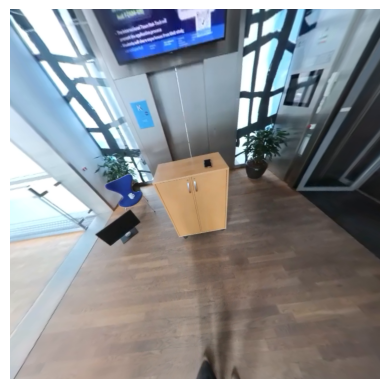

In [10]:
image_chunks = bounding_boxes_to_image_chunks(next_frame, bounding_boxes, orientation="horizontal")
next_image_chunk = find_similar_image_chunk(previous_image_chunk, image_chunks)
display_image(next_image_chunk.image)

In [11]:
# Get camera matrix
K = get_intrinsics_for_chunk(next_image_chunk)
K

array([[215.88321445,   0.        , 350.        ],
       [  0.        , 215.88321445, 350.        ],
       [  0.        ,   0.        ,   1.        ]])

Get object mesh in previous pose relative to camera in OpenCV format

In [73]:
import numpy as np

unposed_mesh = read_trimesh(unposed_path)
identity_rotation = np.eye(3, dtype=np.float32)
zero_translation = np.zeros(3, dtype=np.float32)
scaled_mesh = apply_mesh_transforms(unposed_mesh, identity_rotation, zero_translation, chunk_relative_scale)

In [ ]:
import cv2
import numpy as np

# convert to opencv format
cv_vertices = scaled_mesh.vertices.astype(np.float32)
cv_tris = scaled_mesh.faces.astype(np.int32)
chunk_rotation_matrix = np.array(chunk_relative_rotation, dtype=np.float32)
cv_rotation, _ = cv2.Rodrigues(chunk_rotation_matrix)
cv_translation = np.array(chunk_relative_translation, dtype=np.float32).reshape(3, 1)

Chosen Y-up -> CV mapping:
 [[-1.  0.  0.]
 [ 0.  0. -1.]
 [ 0. -1.  0.]]
Calibration in-frame ratio on previous chunk: 1.0


Run RAPID and apply new transforms to object

In [75]:
import cv2

_, cv_rotation_new, cv_translation_new, _ = cv2.rapid.rapid(
    img=next_image_chunk.image,
    num=40,
    len=10,
    pts3d=cv_vertices,
    tris=cv_tris,
    K=K,
    rvec=cv_rotation,
    tvec=cv_translation
)

In [ ]:
# Convert RAPID output back to chunk/world transforms
next_rotation_chunk, _ = cv2.Rodrigues(cv_rotation_new)
next_translation_chunk = cv_translation_new.reshape(3)

# Pose in world
rot, trans = adjust_transforms_by_chunk_rotation([next_rotation_chunk], [next_translation_chunk], next_image_chunk)
next_rotation_world = rot[0]
next_translation_world = trans[0]

Visualize pose difference

In [80]:
unposed_mesh = read_trimesh(unposed_path)
next_world_mesh = apply_mesh_transforms(unposed_mesh, next_rotation_world, next_translation_world, scale)
unposed_mesh = read_trimesh(unposed_path)
previous_world_mesh = apply_mesh_transforms(unposed_mesh, rotation, translation, scale)

In [82]:
import open3d as o3d
from src.util import trimesh_to_open3d, render_scene
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.55, origin=[0, 0, 0])

render_scene([trimesh_to_open3d(previous_world_mesh).paint_uniform_color([1, 0, 0]),
              trimesh_to_open3d(next_world_mesh).paint_uniform_color([0, 1, 0]),
              character_placeholder,
              coordinate_frame])

[Open3D WARNING] invalid color in PaintUniformColor, clipping to [0, 1]


In [79]:
character_placeholder = get_character_placeholder()
coordinate_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=0.55, origin=[0, 0, 0])
render_scene([trimesh_to_open3d(next_world_mesh), character_placeholder, coordinate_frame])

[Open3D WARNING] invalid color in PaintUniformColor, clipping to [0, 1]


In [61]:
#TODO: convert to opencv format
#TODO: perform RAPID step
#TODO: adjust by chunk rotation
#TODO: write back local and global rotation and set next iamge chunk